In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout

In [2]:
import warnings
warnings.filterwarnings('ignore')
sns.set(style="whitegrid", palette="muted")

In [3]:
# ==========================================
# 1. DATA LOADING & PREPROCESSING
# ==========================================
df = pd.read_csv('crypto_combine.csv')

In [4]:
df.head()

,Crypto,Date,Open,High,Low,Close
0,BTC,12/31/19,7254.0,7309.0,7132.0,7171.0
1,BTC,12/30/19,7402.0,7430.0,7217.0,7254.0
2,BTC,12/29/19,7334.0,7529.0,7295.0,7402.0
3,BTC,12/28/19,7235.0,7359.0,7235.0,7334.0
4,BTC,12/27/19,7208.0,7267.0,7087.0,7235.0


In [5]:
df.tail()

,Crypto,Date,Open,High,Low,Close
7894,XRP,1/5/19,0.36,0.36,0.35,0.36
7895,XRP,1/4/19,0.36,0.36,0.35,0.36
7896,XRP,1/3/19,0.37,0.38,0.35,0.36
7897,XRP,1/2/19,0.36,0.37,0.36,0.37
7898,XRP,1/1/19,0.35,0.36,0.34,0.36


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7899 entries, 0 to 7898
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Crypto  7899 non-null   object 
 1   Date    7899 non-null   object 
 2   Open    7899 non-null   float64
 3   High    7899 non-null   float64
 4   Low     7899 non-null   float64
 5   Close   7899 non-null   float64
dtypes: float64(4), object(2)
memory usage: 370.4+ KB


In [7]:
# Convert Date to datetime format and sort
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(by='Date')

# Label Encoding for Crypto types (BTC, ETH, etc.)
le = LabelEncoder()
df['Crypto_Enc'] = le.fit_transform(df['Crypto'])

# Feature Engineering
# Features: Open, High, Low, Crypto_Enc, Month, Day
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day

features = ['Open', 'High', 'Low', 'Crypto_Enc', 'Month', 'Day']
X = df[features]
y = df['Close']

# Scaling features (Essential for LSTM and helpful for Regression)
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.values.reshape(-1, 1))

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.2, random_state=42)

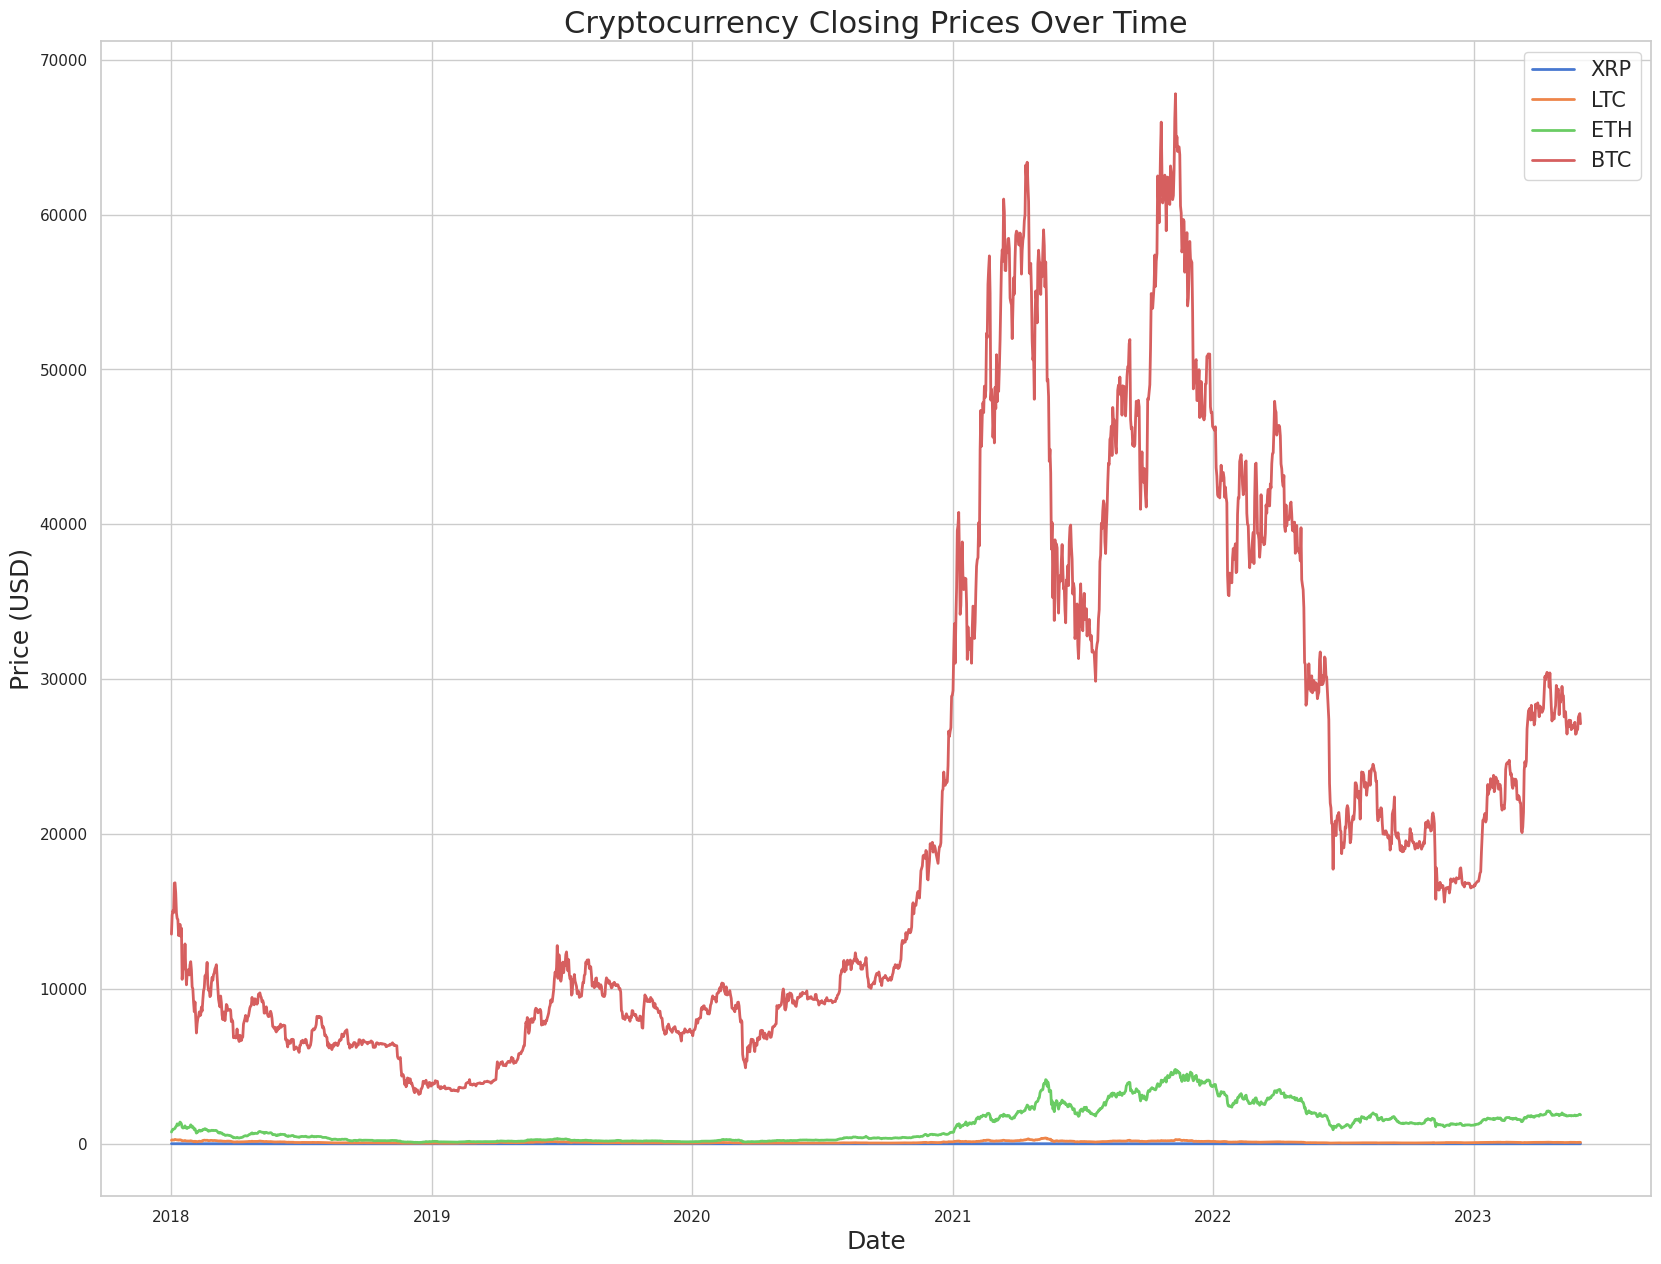

In [8]:
plt.figure(figsize=(20, 15))
for crypto in df['Crypto'].unique():
    subset = df[df['Crypto'] == crypto]
    plt.plot(subset['Date'], subset['Close'], label=crypto, linewidth=2)
plt.title('Cryptocurrency Closing Prices Over Time', fontsize=22)
plt.xlabel('Date', fontsize=18)
plt.ylabel('Price (USD)', fontsize=18)
plt.legend(fontsize=15)
plt.show()

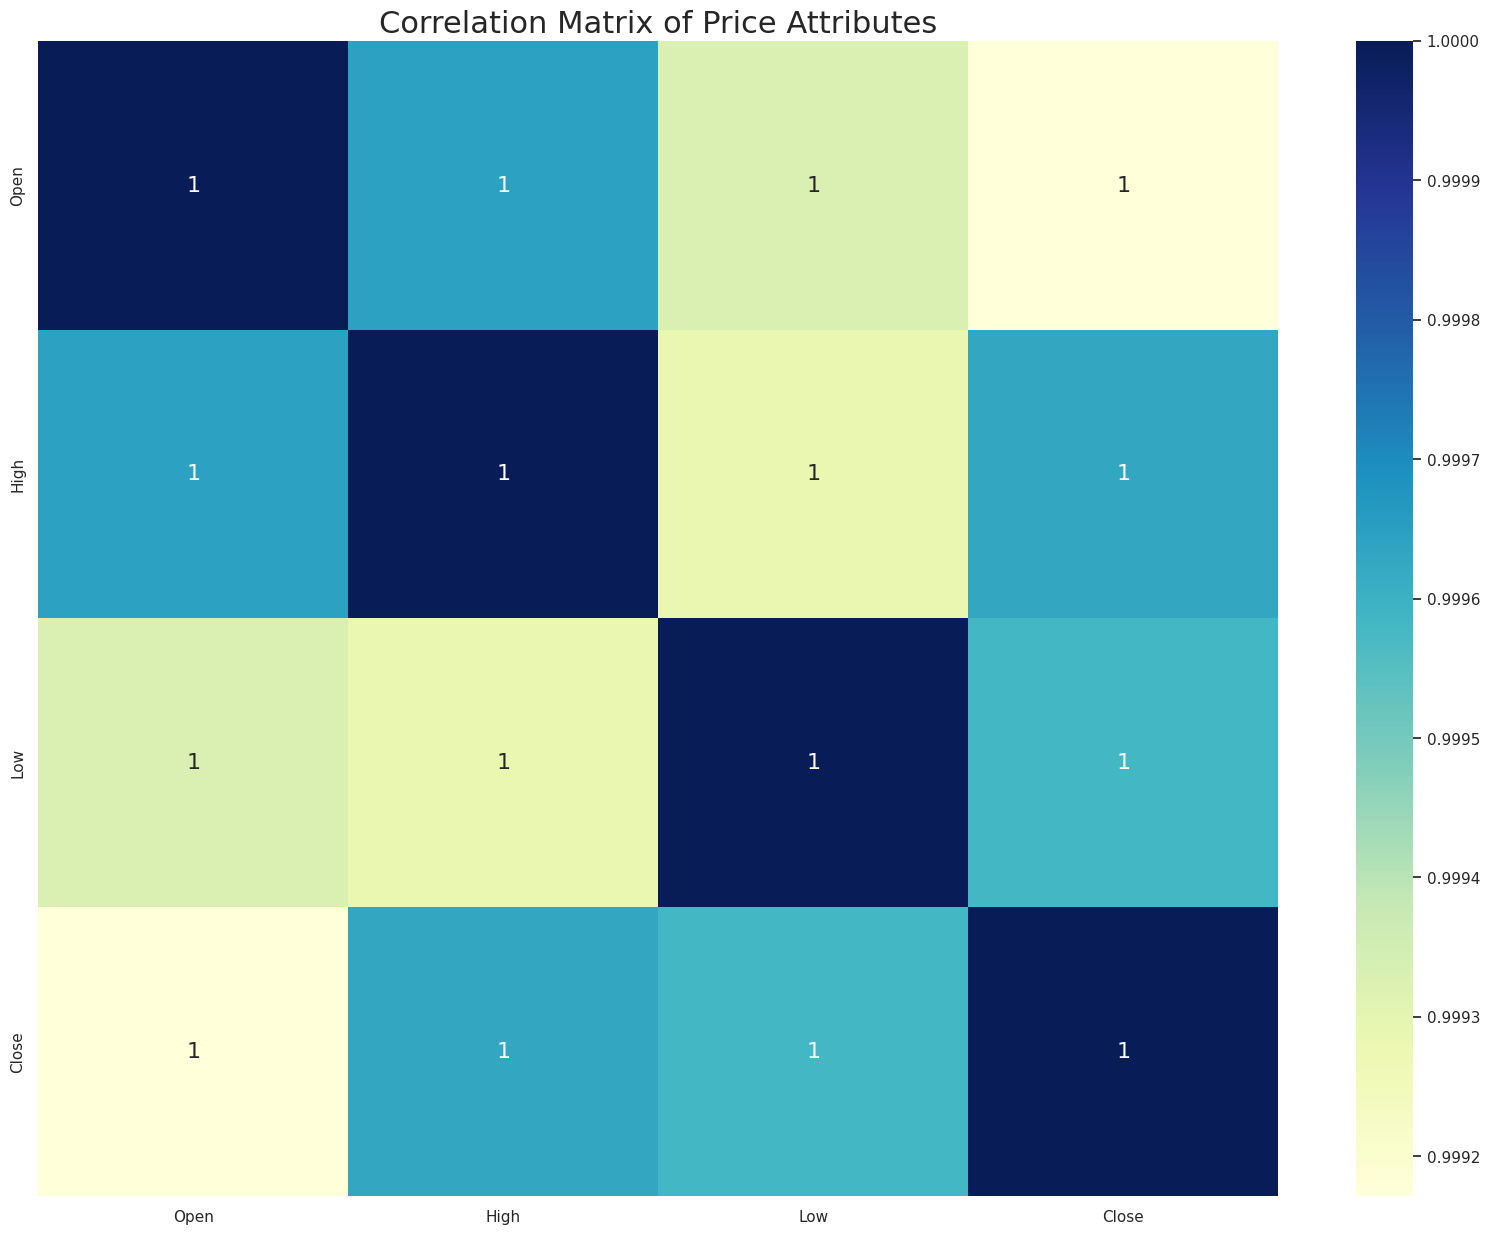

In [9]:
# 2. Correlation Heatmap
plt.figure(figsize=(20, 15))
sns.heatmap(df[['Open', 'High', 'Low', 'Close']].corr(), annot=True, cmap='YlGnBu', annot_kws={"size": 16})
plt.title('Correlation Matrix of Price Attributes', fontsize=22)
plt.show()

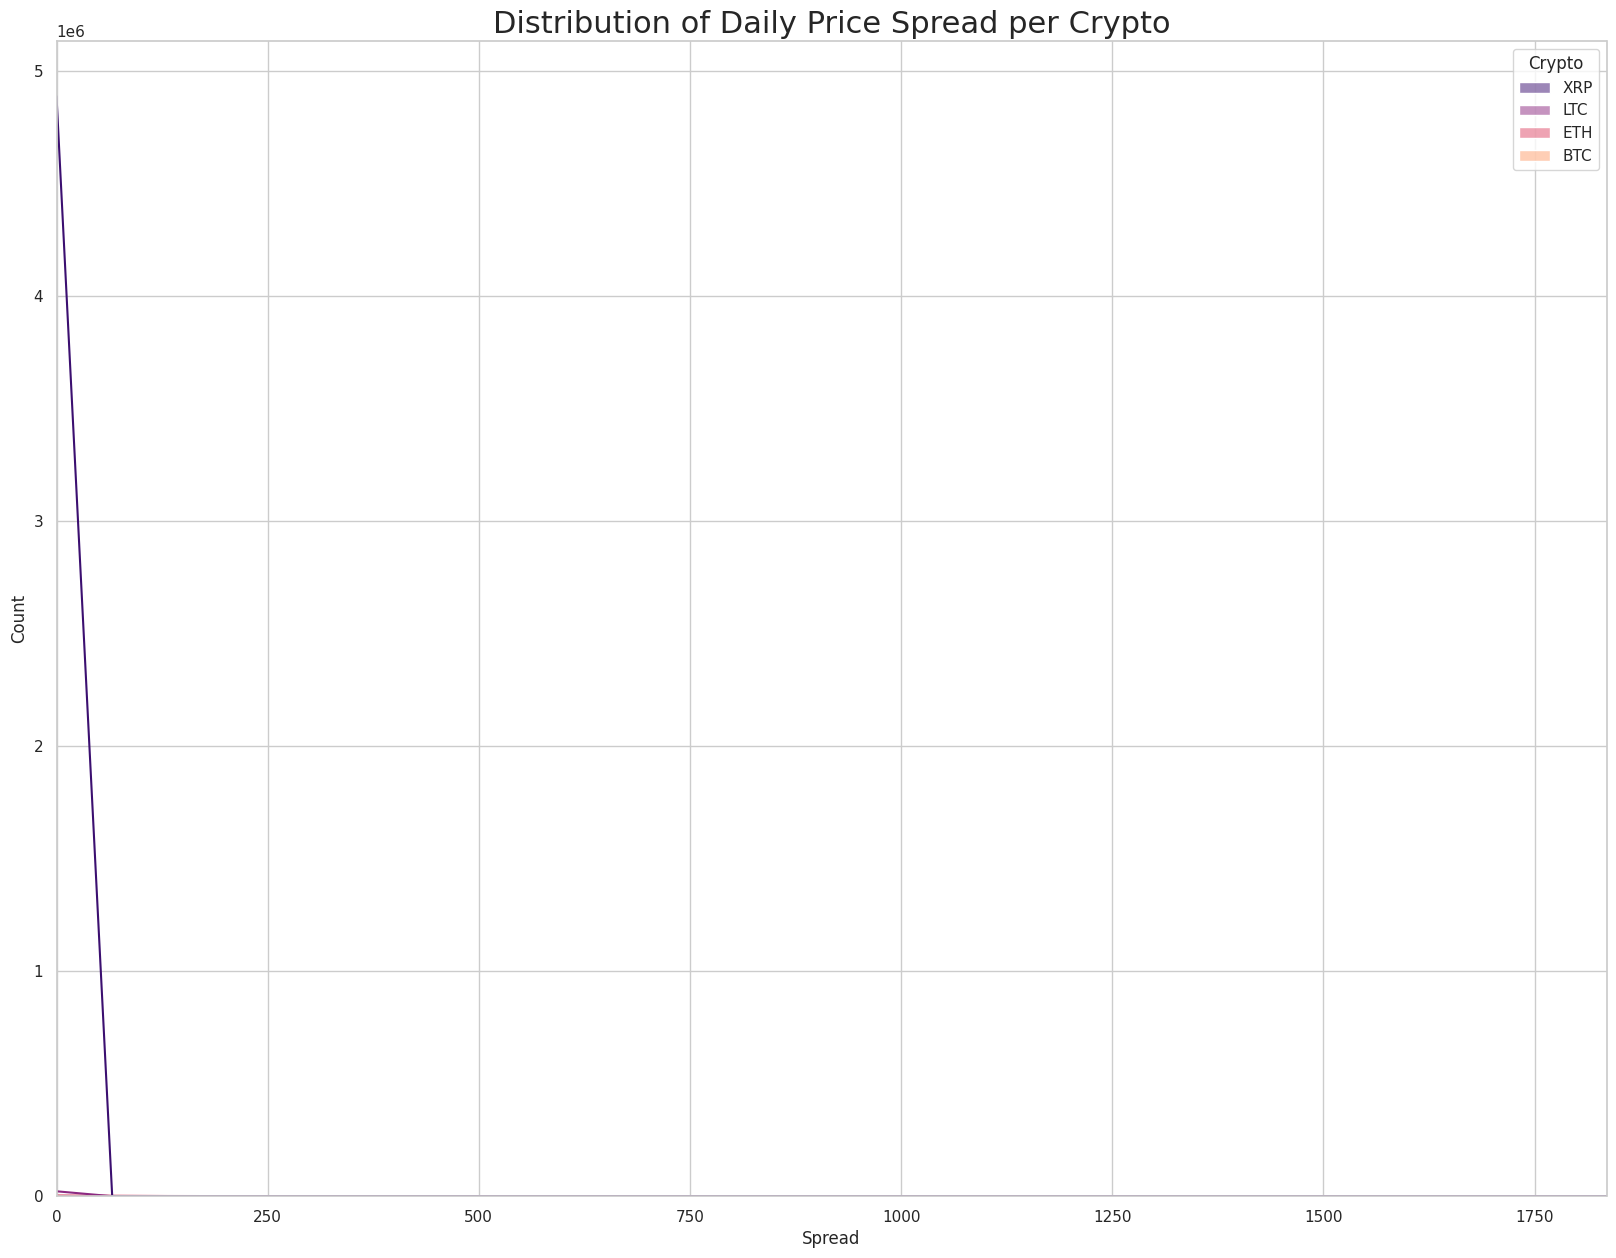

In [10]:
plt.figure(figsize=(20, 15))
df['Spread'] = df['High'] - df['Low']
sns.histplot(df, x='Spread', hue='Crypto', bins=50, kde=True, palette='magma')
plt.title('Distribution of Daily Price Spread per Crypto', fontsize=22)
plt.xlim(0, df['Spread'].quantile(0.95)) # Focus on the main distribution
plt.show()

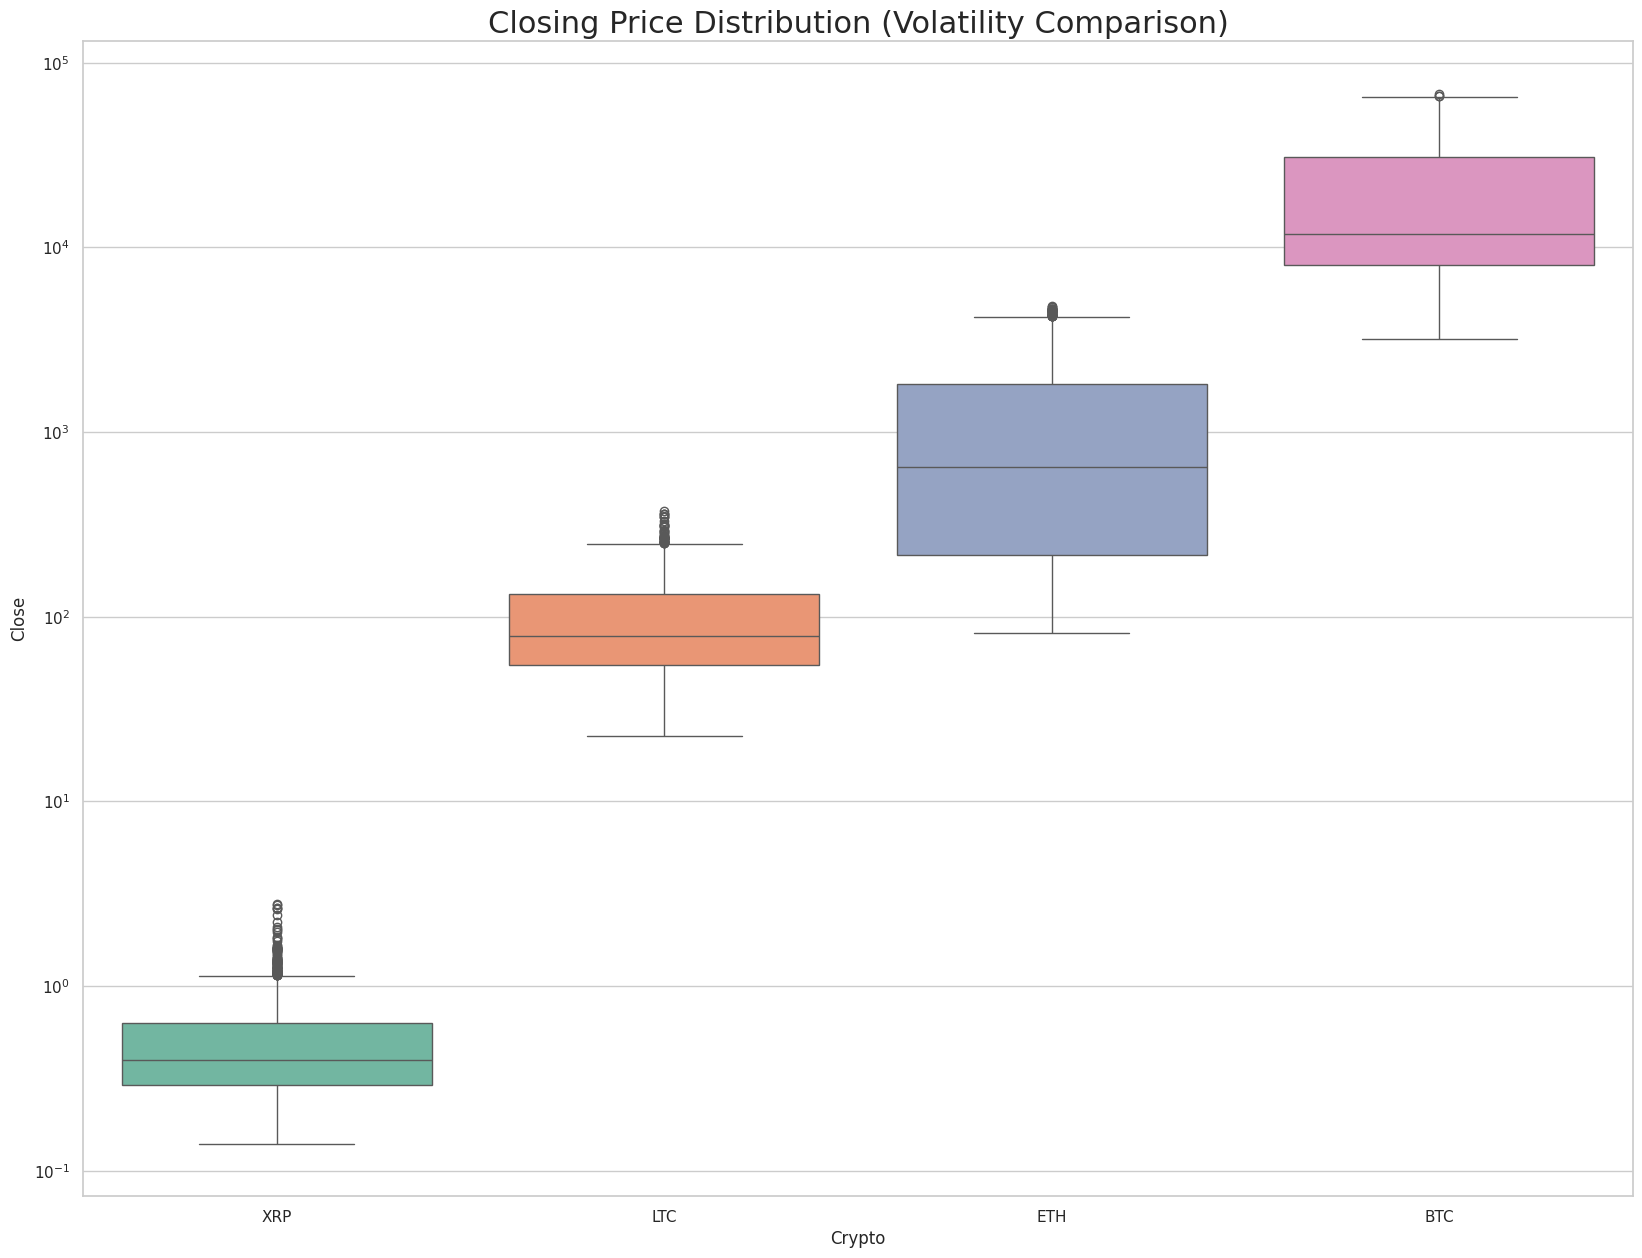

In [11]:
plt.figure(figsize=(20, 15))
sns.boxplot(x='Crypto', y='Close', data=df, palette='Set2')
plt.title('Closing Price Distribution (Volatility Comparison)', fontsize=22)
plt.yscale('log') # Log scale for better visibility of smaller priced coins like XRP
plt.show()

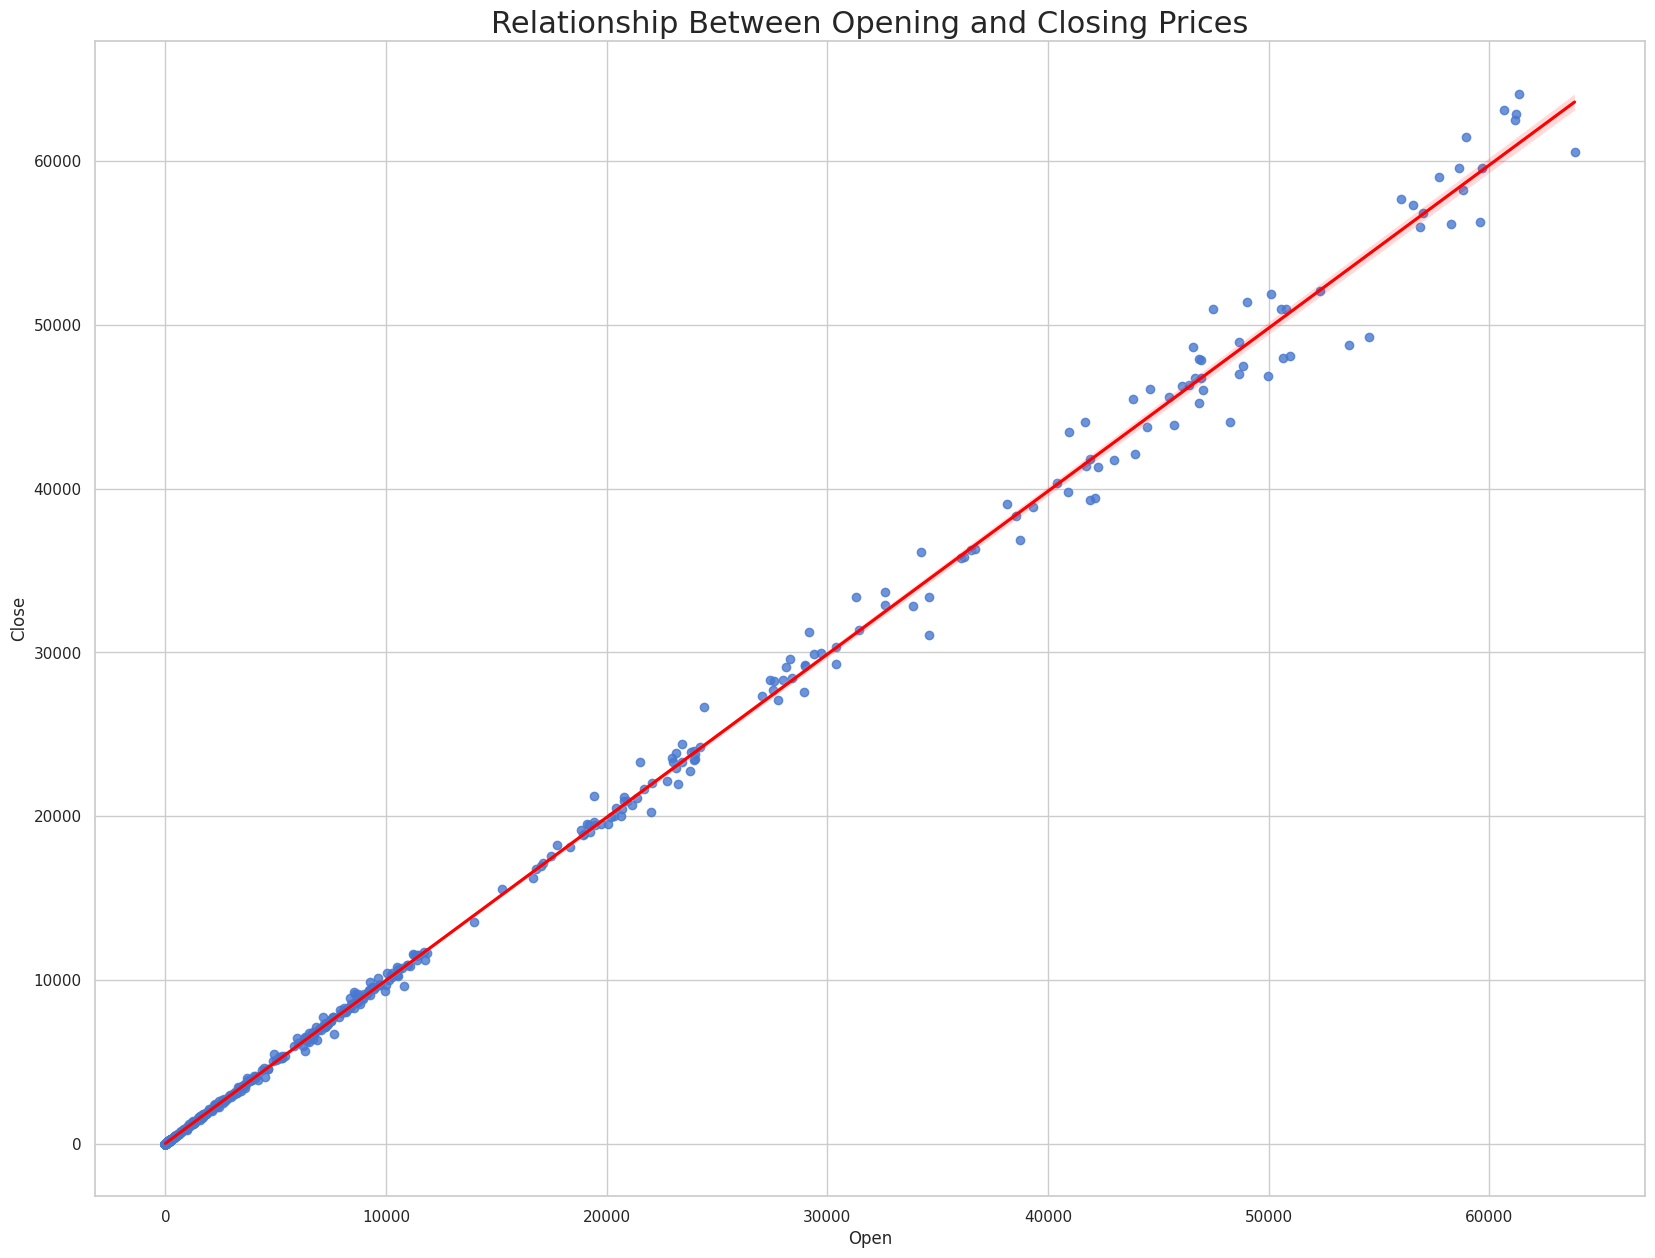

In [12]:
plt.figure(figsize=(20, 15))
sns.regplot(x='Open', y='Close', data=df.sample(1000), line_kws={"color": "red"})
plt.title('Relationship Between Opening and Closing Prices', fontsize=22)
plt.show()

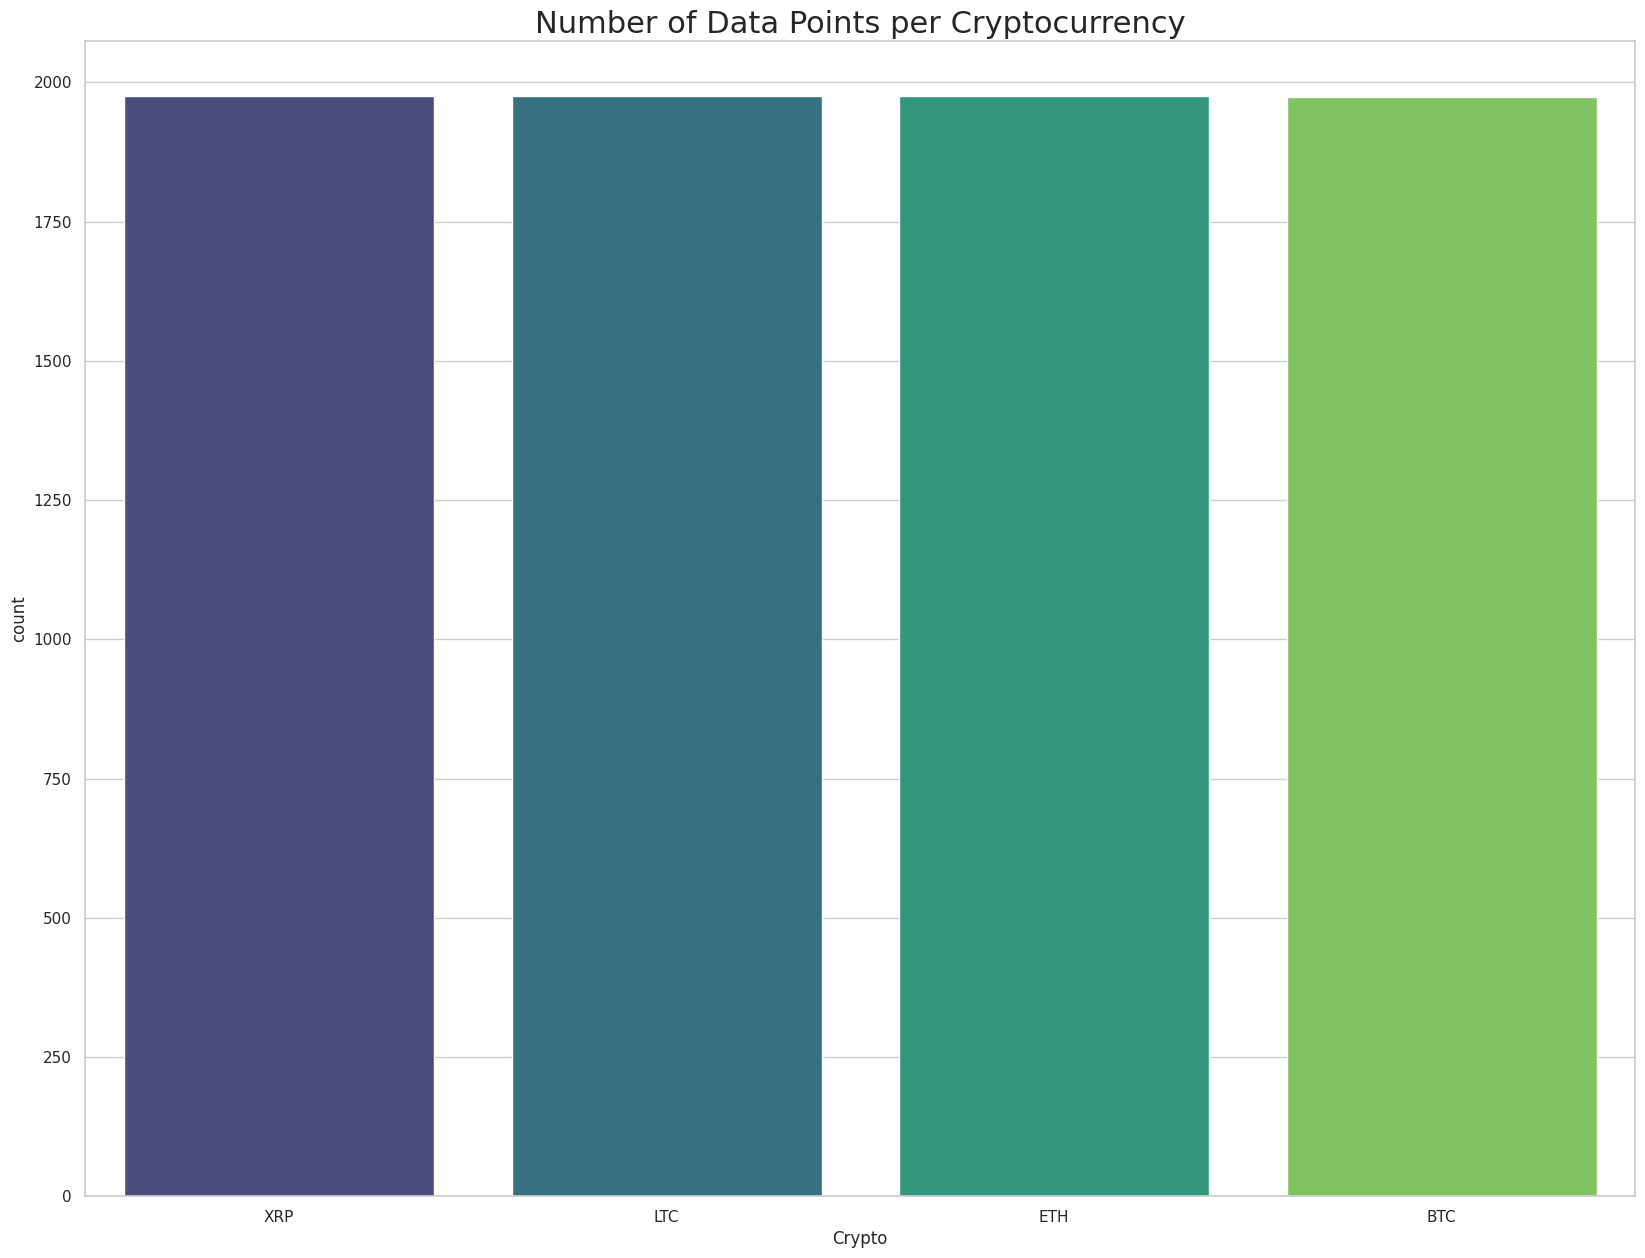

In [13]:
plt.figure(figsize=(20, 15))
sns.countplot(x='Crypto', data=df, palette='viridis')
plt.title('Number of Data Points per Cryptocurrency', fontsize=22)
plt.show()

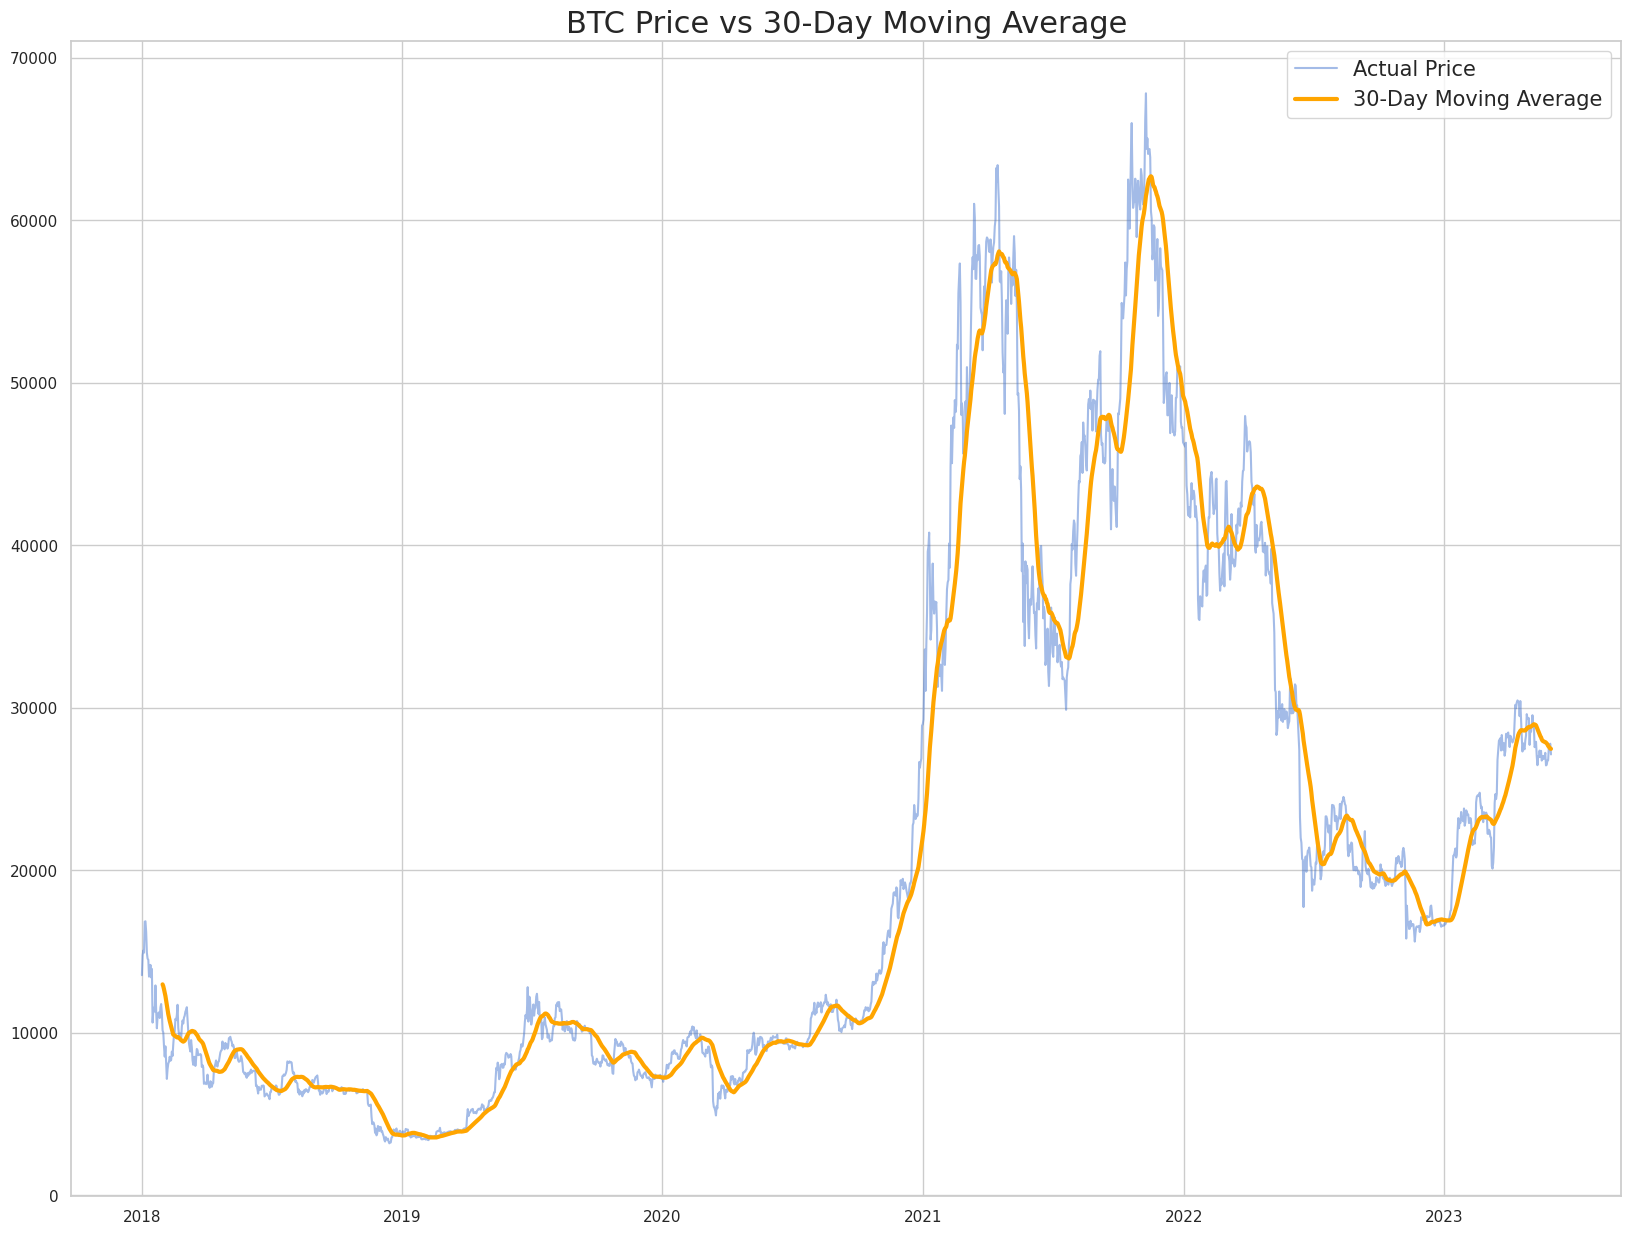

In [14]:
plt.figure(figsize=(20, 15))
btc_data = df[df['Crypto'] == 'BTC'].copy()
btc_data['MA30'] = btc_data['Close'].rolling(window=30).mean()
plt.plot(btc_data['Date'], btc_data['Close'], label='Actual Price', alpha=0.5)
plt.plot(btc_data['Date'], btc_data['MA30'], label='30-Day Moving Average', color='orange', linewidth=3)
plt.title('BTC Price vs 30-Day Moving Average', fontsize=22)
plt.legend(fontsize=15)
plt.show()

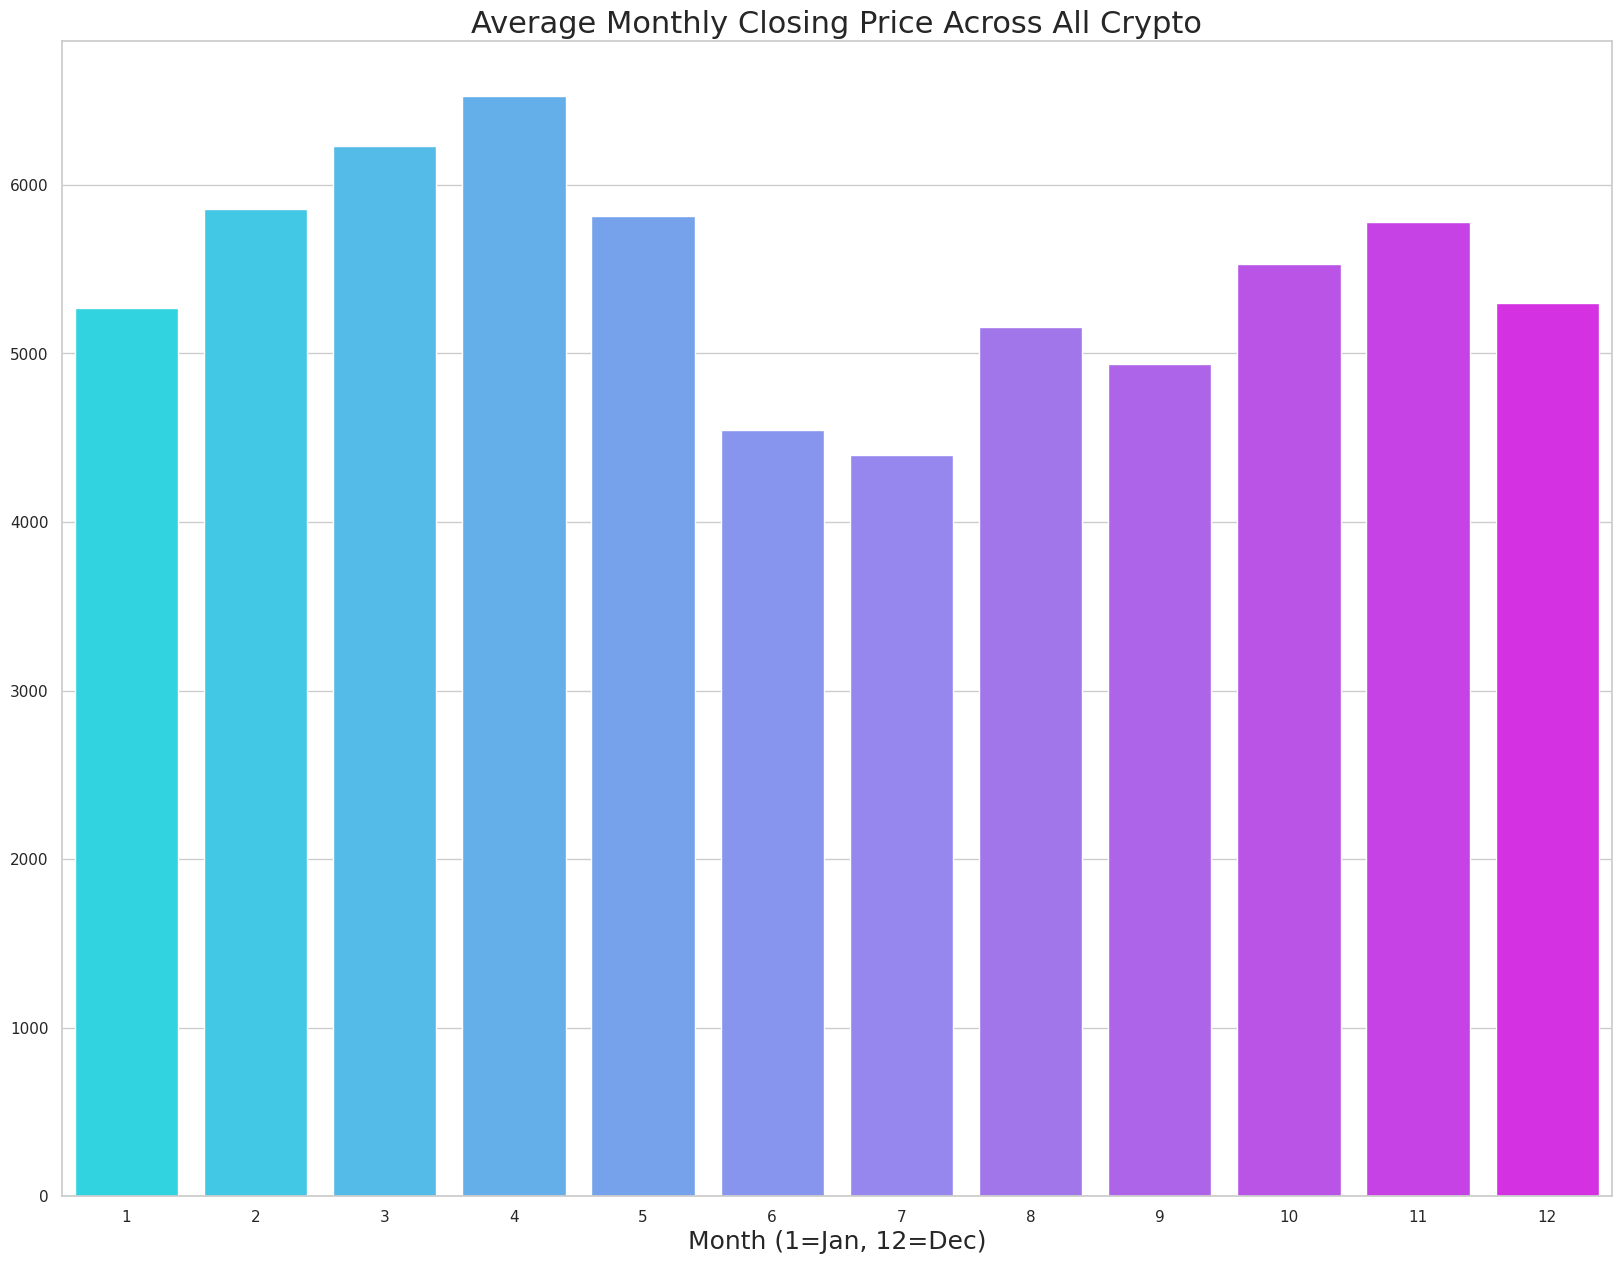

In [15]:
plt.figure(figsize=(20, 15))
monthly_avg = df.groupby('Month')['Close'].mean()
sns.barplot(x=monthly_avg.index, y=monthly_avg.values, palette='cool')
plt.title('Average Monthly Closing Price Across All Crypto', fontsize=22)
plt.xlabel('Month (1=Jan, 12=Dec)', fontsize=18)
plt.show()

In [16]:
# ==========================================
# 3. MODELS: 2 ML AND 1 DL
# ==========================================

# --- ML Model 1: Random Forest Regressor ---
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train.ravel())
rf_preds = rf_model.predict(X_test)

# --- ML Model 2: Linear Regression ---
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

# --- DL Model: Long Short-Term Memory (LSTM) ---
# Reshape for LSTM: [Samples, Time Steps, Features]
X_train_lstm = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
X_test_lstm = X_test.reshape((X_test.shape[0], 1, X_test.shape[1]))

lstm_model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(1, X_train.shape[1])),
    Dropout(0.2),
    LSTM(32),
    Dense(16, activation='relu'),
    Dense(1)
])

lstm_model.compile(optimizer='adam', loss='mean_squared_error')
lstm_model.fit(X_train_lstm, y_train, epochs=20, batch_size=32, verbose=0)
lstm_preds = lstm_model.predict(X_test_lstm)

50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


In [17]:
# ==========================================
# 4. RANKING TABLE & VISUALIZATION
# ==========================================

def get_metrics(y_true, y_pred, model_name):
    return {
        'Model': model_name,
        'R2 Score': r2_score(y_true, y_pred),
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred))
    }

metrics_list = [
    get_metrics(y_test, rf_preds, 'Random Forest'),
    get_metrics(y_test, lr_preds, 'Linear Regression'),
    get_metrics(y_test, lstm_preds, 'LSTM (Deep Learning)')
]

# Create and Sort Rank Table by R2 Score (Higher is better)
rank_df = pd.DataFrame(metrics_list).sort_values(by='R2 Score', ascending=False).reset_index(drop=True)
rank_df.index += 1
rank_df.index.name = 'Rank'

print("\n" + "="*30)
print("MODEL PERFORMANCE RANKING")
print("="*30)
print(rank_df)


MODEL PERFORMANCE RANKING
                     Model  R2 Score       MAE      RMSE
Rank                                                    
1        Linear Regression  0.999568  0.001043  0.003729
2            Random Forest  0.999305  0.001389  0.004726
3     LSTM (Deep Learning)  0.998987  0.003160  0.005708


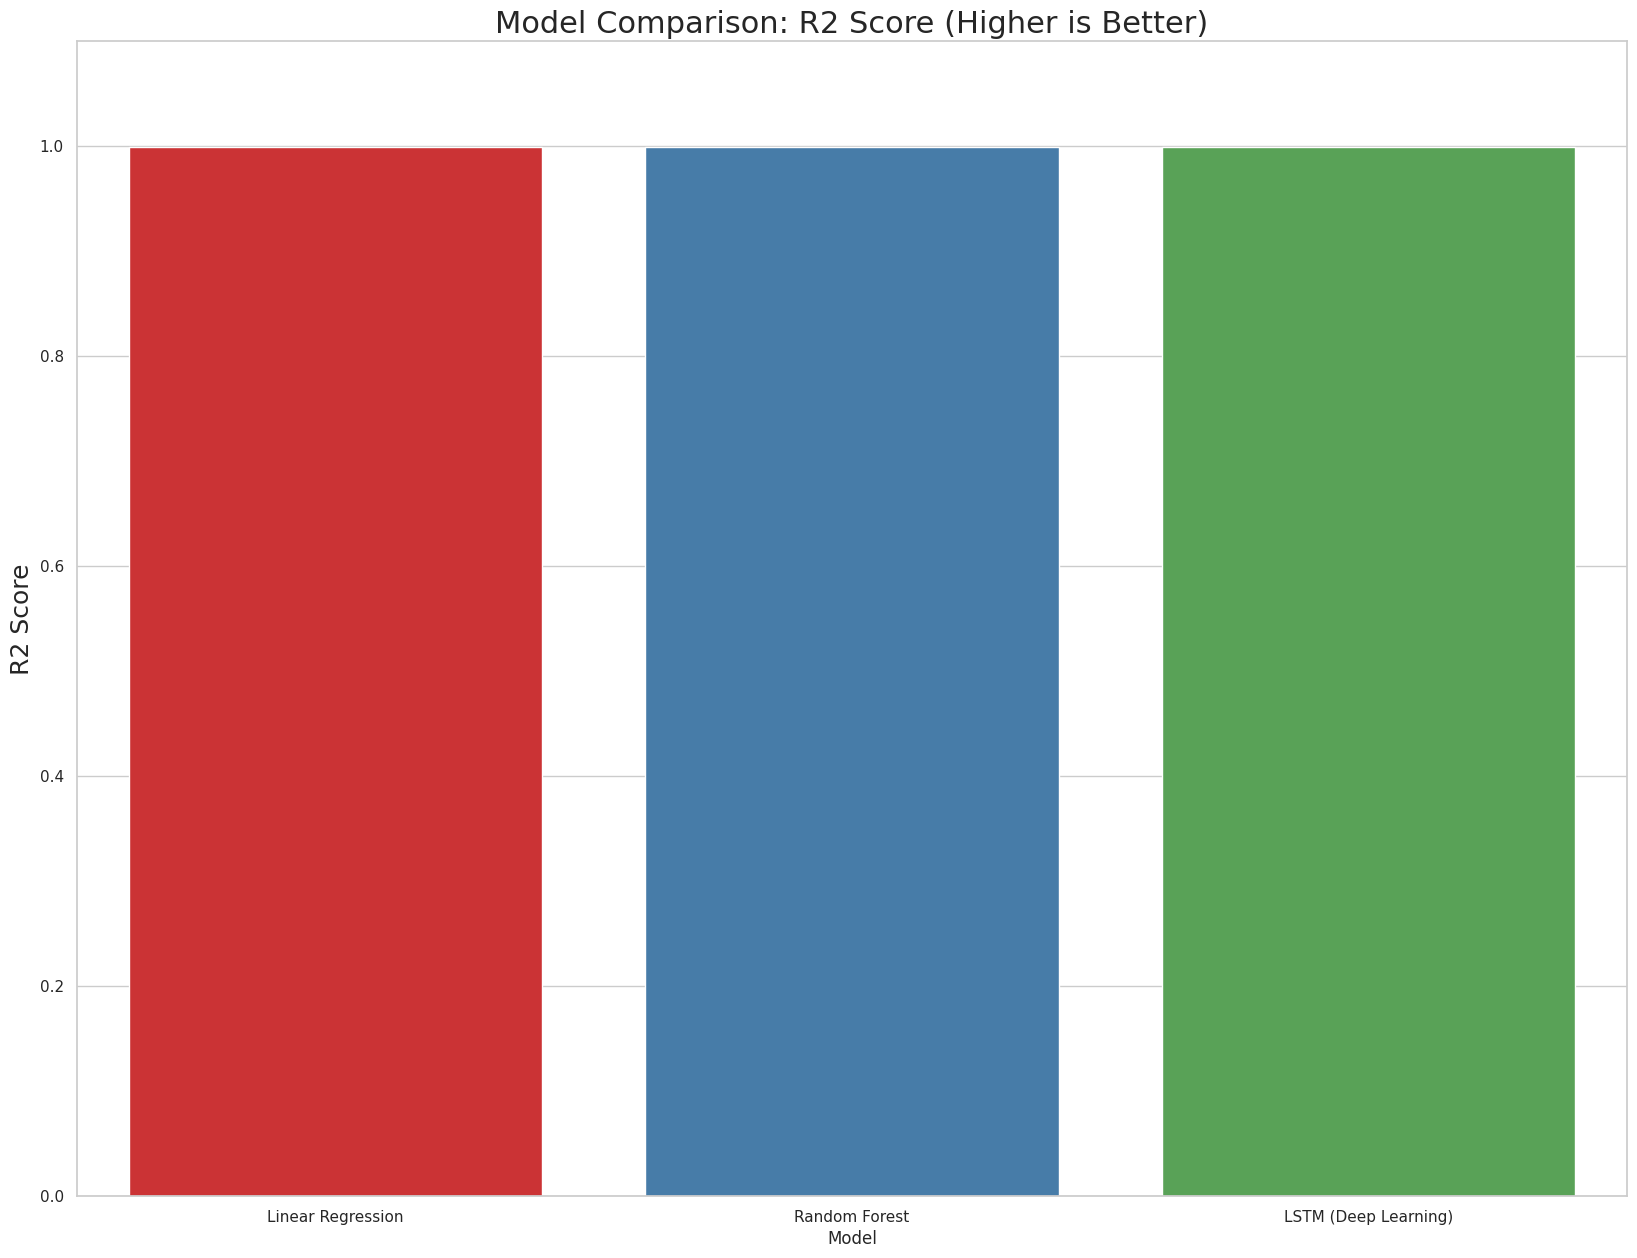

In [18]:
# Final Visualization: Performance Comparison
plt.figure(figsize=(20, 15))
sns.barplot(x='Model', y='R2 Score', data=rank_df, palette='Set1')
plt.title('Model Comparison: R2 Score (Higher is Better)', fontsize=22)
plt.ylabel('R2 Score', fontsize=18)
plt.ylim(0, 1.1)
plt.show()